## Synthetic Control

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

collisions_ca = pd.read_csv(r"data/California_Collisions_Clean.csv")

In [1]:
!pip install sdid

  Using cached sdid-0.3.5-py3-none-any.whl.metadata (15 kB)
  Using cached clarabel-0.11.1-cp39-abi3-win_amd64.whl.metadata (4.9 kB)
Using cached sdid-0.3.5-py3-none-any.whl (16 kB)
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 1.3/1.3 MB 10.9 MB/s  0:00:00
Using cached clarabel-0.11.1-cp39-abi3-win_amd64.whl (887 kB)
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 2.2/2.2 MB 9.7 MB/s  0:00:00
   ---------------------------------------- 0.0/7.5 MB ? eta -:--:--
   ------------------ --------------------- 3.4/7.5 MB 15.5 MB/s eta 0:00:01
   ---------------------------------------  7.3/7.5 MB 17.4 MB/s eta 0:00:01
   ---------------------------------------- 7.5/7.5 MB 15.9 MB/s  0:00:00

   ---------------------------------------- 0/7 [joblib]
   ---------------------------------------- 0/7 [joblib]
   ---------------------------------------- 0/7 [joblib]
  

In [2]:
from sdid import SyntheticDiffInDiff

## Fix Data before Modeling

In [9]:
#restructure data
monthly_did_data = (collisions_ca.groupby(['CDTFA_CITY', 'year_month']).size().reset_index(name='crashes'))

monthly_did_data['year_month'] = pd.PeriodIndex(monthly_did_data['year_month'], freq='M').to_timestamp()

monthly_did_data = monthly_did_data[monthly_did_data['CDTFA_CITY'].notna()]

print(monthly_did_data.shape)
print(monthly_did_data.columns)

(28807, 3)
Index(['CDTFA_CITY', 'year_month', 'crashes'], dtype='object')


In [ ]:
TREATMENT_DATE = pd.Timestamp('2014-04-01')  #Closest date after March 18th, 2014
TREATED_CITY   = 'San Francisco'

monthly_did_data['post'] = (monthly_did_data['year_month'] >= TREATMENT_DATE).astype(int)
monthly_did_data['treat'] = (monthly_did_data['CDTFA_CITY'] == TREATED_CITY).astype(int)


###  Find Control Cities

In [11]:
#get rid of cities that don't have recorded crashes every month
counts = monthly_did_data.groupby('CDTFA_CITY').size().sort_values(ascending=False)
#record city names with 84 enteries
city_list = counts[counts == 84].index


monthly_did_data = monthly_did_data[monthly_did_data['CDTFA_CITY'].isin(city_list)]

In [12]:
for c in monthly_did_data['CDTFA_CITY'].unique():
  print(c)

Agoura Hills
Alhambra
Anaheim
Arcadia
Atascadero
Azusa
Bakersfield
Baldwin Park
Banning
Bell
Benicia
Berkeley
Brea
Buena Park
Burbank
Calabasas
Camarillo
Campbell
Capitola
Carlsbad
Carpinteria
Carson
Chico
Chula Vista
Colton
Commerce
Compton
Corona
Corte Madera
Costa Mesa
Cupertino
Daly City
Dana Point
Danville
East Palo Alto
Eastvale
El Cajon
El Monte
Elk Grove
Emeryville
Fairfield
Fontana
Fountain Valley
Fresno
Fullerton
Galt
Garden Grove
Gilroy
Glendale
Goleta
Hanford
Hawthorne
Hayward
Hesperia
Huntington Beach
Industry
Irvine
Jurupa Valley
La Cañada Flintridge
La Mesa
Laguna Hills
Lake Elsinore
Lake Forest
Lancaster
Lathrop
Lemon Grove
Lincoln
Livermore
Lodi
Loma Linda
Long Beach
Los Alamitos
Los Gatos
Lynwood
Madera
Manteca
Menifee
Menlo Park
Merced
Milpitas
Mission Viejo
Modesto
Montebello
Monterey Park
Moorpark
Moreno Valley
Murrieta
National City
Newark
Norco
Novato
Oakland
Oceanside
Ontario
Orange
Oroville
Oxnard
Palmdale
Paramount
Pasadena
Perris
Pismo Beach
Placentia
Pleasan

### Convert Year Month Variable to a numeric counter

In [13]:
#Convert time to readable format
# Convert year_month to numeric (months since first period)
monthly_did_data['time_numeric'] = (
    (monthly_did_data['year_month'].dt.year - monthly_did_data['year_month'].dt.year.min()) * 12 +
    (monthly_did_data['year_month'].dt.month - monthly_did_data['year_month'].dt.month.min())
)

min_year = monthly_did_data['year_month'].dt.year.min()
min_month = monthly_did_data['year_month'].dt.month.min()
treatment_numeric = (2014 - min_year) * 12 + (3 - min_month)

## Create Model

In [14]:
model = SyntheticDiffInDiff(
    data        = monthly_did_data,
    outcome_col = 'crashes',
    times_col   = 'time_numeric',
    units_col   = 'CDTFA_CITY',
    treat_col   = 'treat',
    post_col    = 'post',
)

result = model.fit()

INFO:sdid.core:Data validated: 1 treated units, 156 controls, 51 pre-periods, 33 post-periods
INFO:sdid.core:Starting SDID analysis...
INFO:sdid.core:Estimating unit weights...
INFO:sdid.core:Unit regularization: 22.5623
INFO:sdid.core:Unit weights estimated: 34 units with non-zero weights
INFO:sdid.core:Unit intercept: -97.9747
INFO:sdid.core:Estimating time weights...
INFO:sdid.core:Time regularization: 10.0469
INFO:sdid.core:Time weights estimated: 0 periods with non-zero weights
INFO:sdid.core:Time intercept: 0.0000
INFO:sdid.core:Merging weights with data...
INFO:sdid.core:Weights merged successfully
INFO:sdid.core:Running weighted regression...
INFO:sdid.core:Treatment effect: 37.9697
INFO:sdid.core:SDID analysis complete!


In [15]:
print(type(result))
print(dir(result))
print(result)

<class 'numpy.float64'>
['T', '__abs__', '__add__', '__and__', '__array__', '__array_interface__', '__array_namespace__', '__array_priority__', '__array_struct__', '__array_wrap__', '__bool__', '__ceil__', '__class__', '__class_getitem__', '__copy__', '__deepcopy__', '__delattr__', '__dir__', '__divmod__', '__doc__', '__eq__', '__float__', '__floor__', '__floordiv__', '__format__', '__ge__', '__getattribute__', '__getformat__', '__getitem__', '__getnewargs__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__int__', '__invert__', '__le__', '__lshift__', '__lt__', '__mod__', '__mul__', '__ne__', '__neg__', '__new__', '__or__', '__pos__', '__pow__', '__radd__', '__rand__', '__rdivmod__', '__reduce__', '__reduce_ex__', '__repr__', '__rfloordiv__', '__rlshift__', '__rmod__', '__rmul__', '__ror__', '__round__', '__rpow__', '__rrshift__', '__rshift__', '__rsub__', '__rtruediv__', '__rxor__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__sub__', '__subcla

INFO:sdid.core:Creating synthetic control plot...
INFO:sdid.core:Creating raw trends plot...


'==================================================\nSynthetic Difference-in-Differences Results\n==================================================\nTreatment Effect (ATT): 37.9697\nControl units used:    34\nTime periods used:     0\n=================================================='

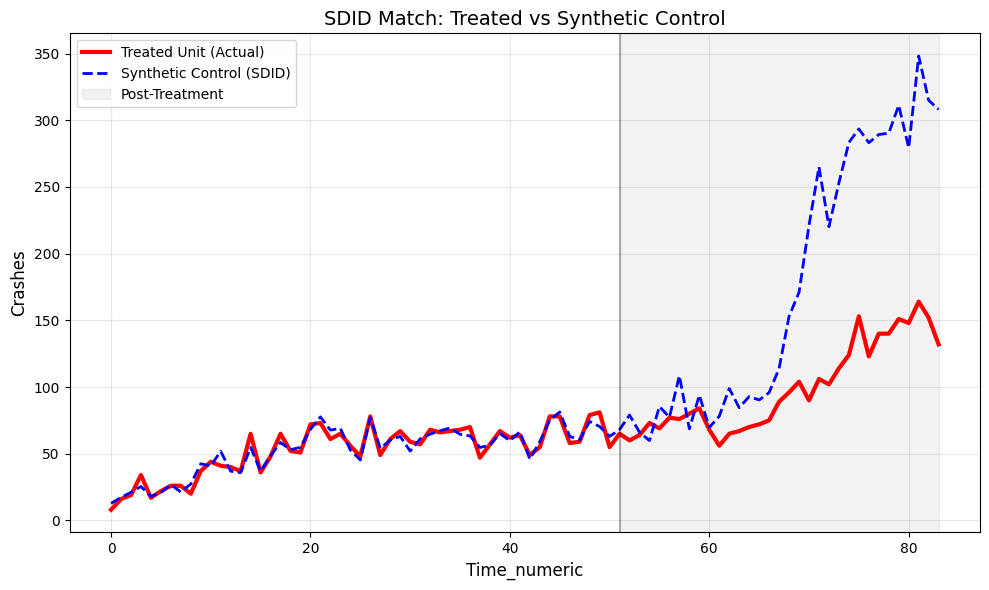

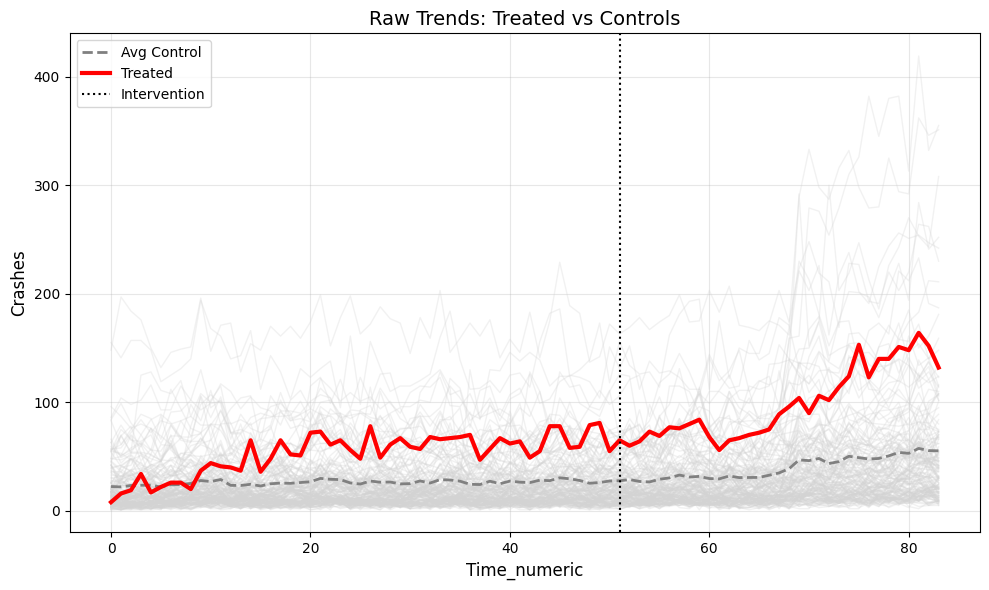

In [16]:
# 1. Synthetic control vs actual SF trends
model.plot_synthetic_control()

# 2. Raw trends for all cities
model.plot_raw_trends()

# Also print the full summary
model.summary()